In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print('Libraries loaded successfully!')


Libraries loaded successfully!


In [2]:
df = pd.read_csv('data/Mall_Customers.csv')
print('Shape:', df.shape)
df.head(10)
print('=== Data Info ===')
df.info()
print('=== Summary Statistics ===')
df.describe()
print('=== Missing Values ===')
print(df.isnull().sum())
print('\nGender distribution:')
print(df['Gender'].value_counts())

Shape: (200, 5)
=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
=== Summary Statistics ===
=== Missing Values ===
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Gender distribution:
Gender
Female    112
Male       88
Name: count, dtype: int64


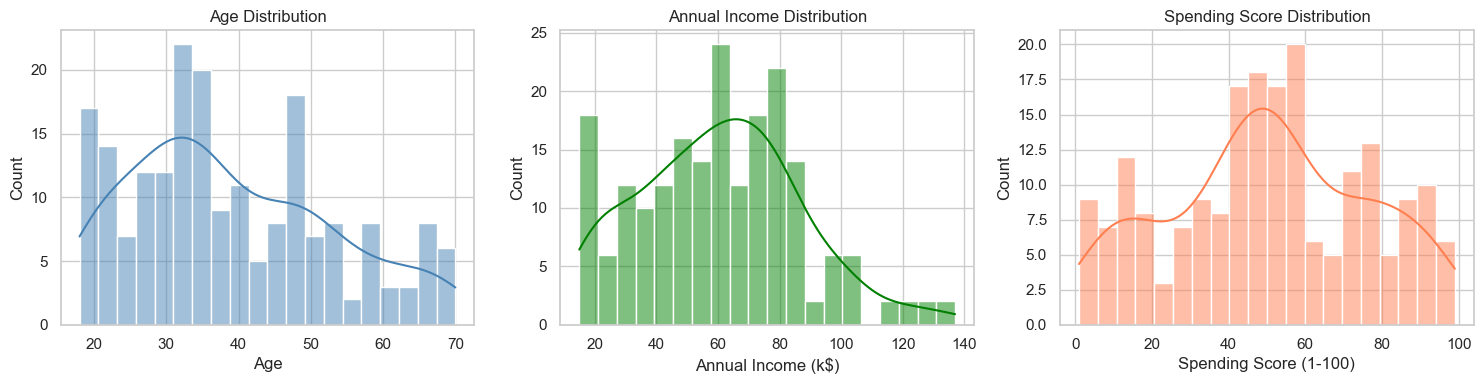

In [8]:
# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, ax=axes[1], color='green')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, ax=axes[2], color='coral')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.savefig('data/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


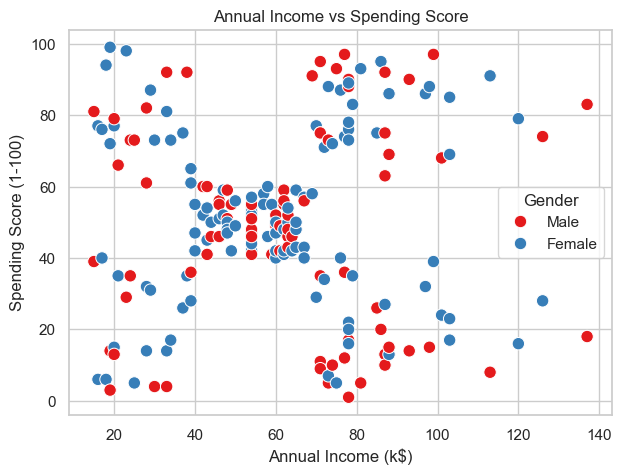

In [10]:
# Scatter: Income vs Spending Score
plt.figure(figsize=(7, 5))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Gender', data=df, palette='Set1', s=80)
plt.title('Annual Income vs Spending Score')
plt.savefig('data/eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


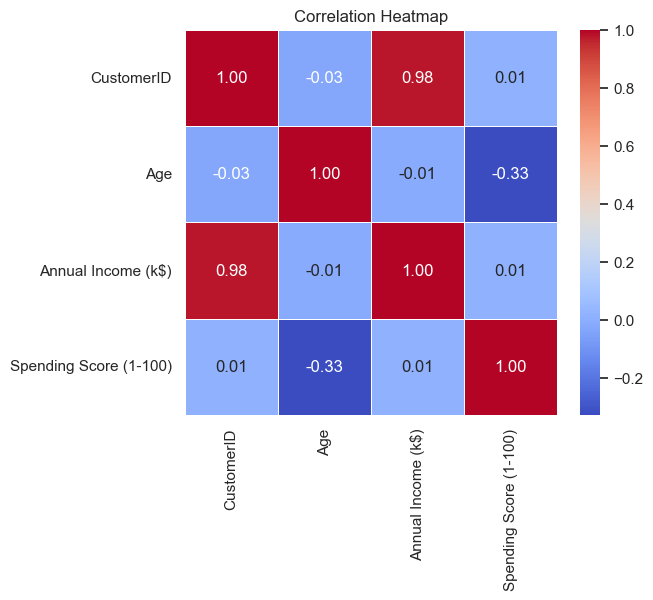

In [11]:
# Correlation heatmap
plt.figure(figsize=(6, 5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.savefig('data/eda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


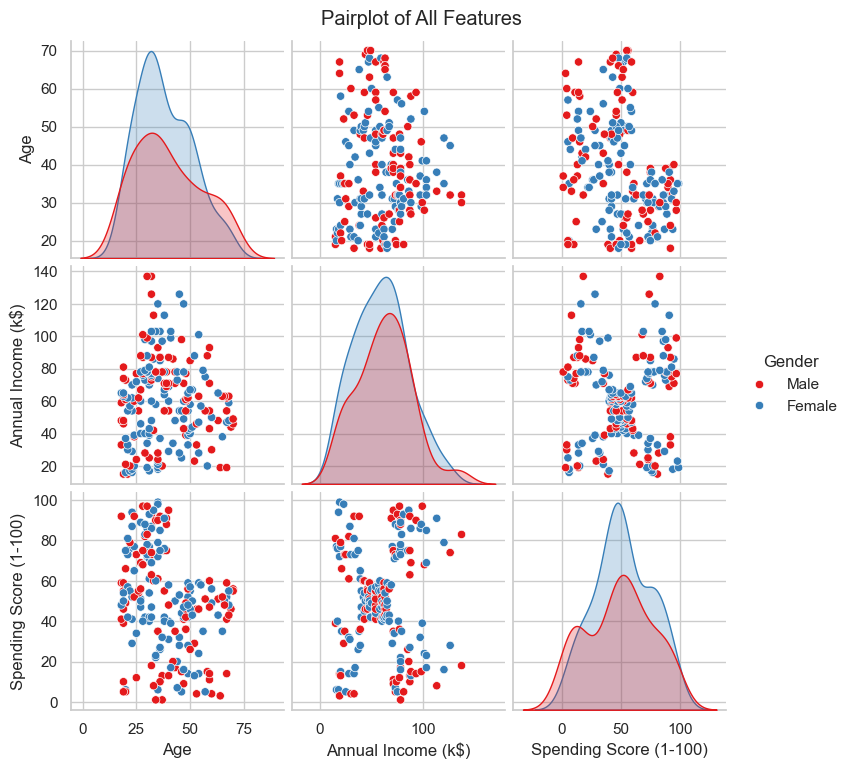

In [14]:
# Pairplot
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']],
             hue='Gender', palette='Set1')
plt.suptitle('Pairplot of All Features', y=1.02)
plt.savefig('data/eda_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# Rename Gender column if needed
if 'Genre' in df.columns:
    df.rename(columns={'Genre': 'Gender'}, inplace=True)

# Encode Gender
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Drop CustomerID
df_clean = df.drop('CustomerID', axis=1)

print('Cleaned dataframe:')
print(df_clean.head())
print('\nShape:', df_clean.shape)


Cleaned dataframe:
   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       0   19                  15                      39
1       0   21                  15                      81
2       1   20                  16                       6
3       1   23                  16                      77
4       1   31                  17                      40

Shape: (200, 4)


In [16]:
# Scale features (important for distance-based algorithms)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

print('Scaled data (first 5 rows):')
print(pd.DataFrame(df_scaled, columns=df_clean.columns).head())


Scaled data (first 5 rows):
     Gender       Age  Annual Income (k$)  Spending Score (1-100)
0 -1.128152 -1.424569           -1.738999               -0.434801
1 -1.128152 -1.281035           -1.738999                1.195704
2  0.886405 -1.352802           -1.700830               -1.715913
3  0.886405 -1.137502           -1.700830                1.040418
4  0.886405 -0.563369           -1.662660               -0.395980


In [17]:
# Save for use in other notebooks
pickle.dump(df_scaled, open('data/df_scaled.pkl', 'wb'))
pickle.dump(df_clean, open('data/df_clean.pkl', 'wb'))
pickle.dump(scaler, open('data/scaler.pkl', 'wb'))

print('Saved: df_scaled.pkl, df_clean.pkl, scaler.pkl')
print('\nPreprocessing complete! Run the individual algorithm notebooks now.')


Saved: df_scaled.pkl, df_clean.pkl, scaler.pkl

Preprocessing complete! Run the individual algorithm notebooks now.
